# nb11 — CITE RNA + protein integration with totalVI

Jointly model measured RNA and ADT counts in the eight nb09 donors, across all
cell populations. No pathway selection, supervised labels or cell matching.
This is within-CITE multimodal integration, not a shared CITE/Multiome space.

**First training:** choose TRAIN and a fresh output folder; GPU recommended.
**Return tomorrow:** leave LOAD selected and Run all. No raw inputs, GPU or
training packages are required to view saved tables and figures.
**Interrupted evaluation:** choose EVALUATE to rebuild analysis from model_input.h5ad
and the saved model, without training. Never switch to TRAIN to recover analysis.

Copy this notebook and src/totalvi_workflow.py to Drive. Existing src helpers from
nb04–10 remain dependencies. Previous notebooks are unchanged.

In [5]:
from pathlib import Path
import json, sys, subprocess
MODE = 'TRAIN'  # LOAD, TRAIN, or EVALUATE; training is always explicit
assert MODE in {'LOAD', 'TRAIN', 'EVALUATE'}
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE = Path.cwd().resolve()
    if not (BASE/'src').is_dir(): BASE = BASE.parent
if MODE != 'LOAD':
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'scanpy>=1.11,<1.12', 'scvi-tools>=1.3,<1.5', 'anndata>=0.11,<0.13'])
sys.path.insert(0, str(BASE))
import pandas as pd
from IPython.display import display, Image
OUTPUT = BASE/'results/totalvi/nb11_run01'
COHORT = BASE/'results/cross_donor/nb09_run01'
SEED = 42
N_HVGS = 3000
TRAINING = dict(max_epochs=300, min_epochs=100, warmup_epochs=50,
                patience=30, accelerator='auto', batch_size=128, n_latent=30)
print('Mode:', MODE, 'Output:', OUTPUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mode: TRAIN Output: /content/drive/MyDrive/multiomics-relationship-modeling/results/totalvi/nb11_run01


## Inputs and model choices
Verify nb09 cohort/source fingerprints. Read paired RNA and ADT by cell ID and
feature position, preventing RNA/protein name collisions. Exclude control-labelled
or all-zero proteins and cells with zero RNA or biological ADT totals; audit all
exclusions. This uses existing QC and does not invent new donor-specific filters.

Select up to 3,000 RNA HVGs from normalized expression with equal donor quotas.
Train on **raw RNA and raw ADT**, not normalized or CLR values. All remaining
proteins enter training. Labels are used only for descriptive evaluation.

No donor/site nuisance covariates: their biological and technical effects are
confounded. This first model learns a joint representation without explicitly
removing those effects. Donor/site mixing alone is not a success criterion.

50-epoch KL warm-up, minimum 100 / maximum 300 epochs, validation ELBO early
stopping after warm-up with patience 30; no learning-rate scheduler. Save final
weights and histories. A final-epoch minimum does not alone prove nonconvergence;
inspect the size of recent changes.

Reference: [totalVI API](https://docs.scvi-tools.org/en/1.4.3/api/reference/scvi.model.TOTALVI.html).

In [ ]:
if MODE == 'TRAIN':
    from configs.paths import CITE_H5AD
    from src.totalvi_workflow import run_totalvi
    # One CITE file only; no Multiome input or copying of raw files for LOAD.
    run_totalvi(CITE_H5AD, COHORT, OUTPUT, seed=SEED, n_hvgs=N_HVGS, **TRAINING)
elif MODE == 'EVALUATE':
    from src.totalvi_workflow import evaluate_saved
    evaluate_saved(OUTPUT, seed=SEED)
else:
    print('Training and evaluation skipped; loading saved outputs below.')

ADT cells read: 1,024/82,896
ADT cells read: 2,048/82,896
ADT cells read: 3,072/82,896
ADT cells read: 4,096/82,896
ADT cells read: 5,120/82,896
ADT cells read: 6,144/82,896
ADT cells read: 7,168/82,896
ADT cells read: 8,192/82,896
ADT cells read: 9,216/82,896
ADT cells read: 10,240/82,896
ADT cells read: 11,264/82,896
ADT cells read: 12,288/82,896
ADT cells read: 13,312/82,896
ADT cells read: 14,336/82,896
ADT cells read: 15,360/82,896
ADT cells read: 16,384/82,896
ADT cells read: 17,408/82,896
ADT cells read: 18,432/82,896
ADT cells read: 19,456/82,896
ADT cells read: 20,480/82,896
ADT cells read: 21,504/82,896
ADT cells read: 22,528/82,896
ADT cells read: 23,552/82,896
ADT cells read: 24,576/82,896
ADT cells read: 25,600/82,896
ADT cells read: 26,624/82,896
ADT cells read: 27,648/82,896
ADT cells read: 28,672/82,896
ADT cells read: 29,696/82,896
ADT cells read: 30,720/82,896
ADT cells read: 31,744/82,896
ADT cells read: 32,768/82,896
ADT cells read: 33,792/82,896
ADT cells read: 34,

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


INFO     Using column names from columns of adata.obsm['protein_counts']                                           


--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
  File "/usr/local/lib/python3.13/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
    ~~~~~~~~~~~~~~~~~^
        self.pub_thread,
        ^^^^^^^^^^^^^^^^
    ...<3 lines>...
        ident=self.topic,
        ^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py", line 820, in send
    msg = self.msg(
        msg_or_type,
    ...<3 lines>...
        metadata=metadata,
    )
  File "/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py", line 661, in msg
    header = self.msg_header(msg_type) if header is None else header
             ~~~~~~~~~~~~~~~^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py", line 644, in msg_header
    return msg_header(self.msg_id, msg_type, self.username, self.s

Training:   0%|          | 0/300 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 30 records. Best score: 1122.181. Signaling Trainer to stop.


In [7]:
required = ['metric_comparison.csv', 'celltype_metrics.csv', 'depth_associations.csv',
            'protein_neighbor_agreement.csv', 'observed_protein_means_by_celltype.csv']
missing = [name for name in required if not (OUTPUT/name).exists()]
if missing:
    raise FileNotFoundError(f'Missing saved outputs: {missing}. For a first run choose TRAIN. '
                            'If model/model.pt and model_input.h5ad already exist, choose EVALUATE instead.')
comparison, types, depths, proteins, marker_means = [pd.read_csv(OUTPUT/name) for name in required]
for name in ['status.json', 'evaluation_status.json', 'input_audit.json', 'training_summary.json']:
    if (OUTPUT/name).exists():
        print(name); display(json.loads((OUTPUT/name).read_text()))

status.json


{'state': 'complete', 'biological_review': 'required'}

evaluation_status.json


{'state': 'complete',
 'n_evaluation_cells': 19317,
 'outputs_sha256': {'protein_panel.csv': 'e4f25a01f882f3c886788ccd087c98d2240bd09da6e6a9ac2601cc8ae9608c73',
  'cell_audit.csv': '7849b681e27b6f078184f208a896dc4e1d38823f396202f7576e72191fc56296',
  'hvg_audit.csv': 'eb38659501f76d9257a9f5502320ee0edd79fd7762fcf015e8082e52cf774315',
  'counts_by_DonorID.csv': 'aa9db685fc6326913f9a77e153543c31f38e0c1ca5644ef09d0024116932b16f',
  'counts_by_Site.csv': 'a9b22a0fb10c0ef96b98a828593715d55b9f29bb33efb5c50c0324924aeea84b',
  'counts_by_cell_type_harmonized.csv': '7a49e60e6ed21574ec6325efdb178e8cc28b9d0f64b5e1980cdd8f719b73e941',
  'training_kl_weight.csv': '0d951ef177f1d3a65a8244f2bc4eb6a1ea286b362ee39857ab4496c5f79c8962',
  'training_validation_loss.csv': 'c3690af145632574e8f6abfeb6de0ceda6caed7971f66c35fef05249c2b54cbb',
  'training_elbo_validation.csv': '2c47610ec194805f9de38dff5a9f7670177c56d9106bf223eba1276c3609e155',
  'training_reconstruction_loss_validation.csv': 'c3b7c35a2648cae269d

input_audit.json


{'source': {'path': '/content/drive/MyDrive/multiomics-relationship-modeling/data/benchmark/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad',
  'file_bytes': 624797386,
  'file_mtime_ns': 1782768387000000000,
  'shape': [90261, 14087],
  'feature_types': {'GEX': 13953, 'ADT': 134},
  'repeated_feature_names': [{'name': 'CD52', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD58', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD2', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD101', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD48', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD244', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD28', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CX3CR1', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD47', 'feature_types': ['GEX', 'ADT']},
   {'name': 'TIGIT', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD86', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD38', 'feature_types': ['GEX', 'ADT']},
   {'name': 'CD14', 'featur

training_summary.json


{'epochs_completed': 222,
 'best_validation_epoch': 191,
 'final_validation_elbo': 1122.8238525390625,
 'final_kl_weight': 1.0,
 'reached_epoch_limit': False,
 'warmup_epochs': 50,
 'note': 'Final weights, not restored best checkpoint. Review curves and biology.'}

## Training and broad cell identity
Compare RNA-only PCA with totalVI on exactly the same fixed donor-quota sample
(up to 20,000 resolved cells). No matching to nb10's cross-assay sample is claimed.
Silhouette uses at most 3,000 cells. Rare types can have unstable estimates: inspect
n_evaluation_cells. Unresolved cells train the model but are excluded from these
label-based evaluations. Purity/label agreement are related internal diagnostics.

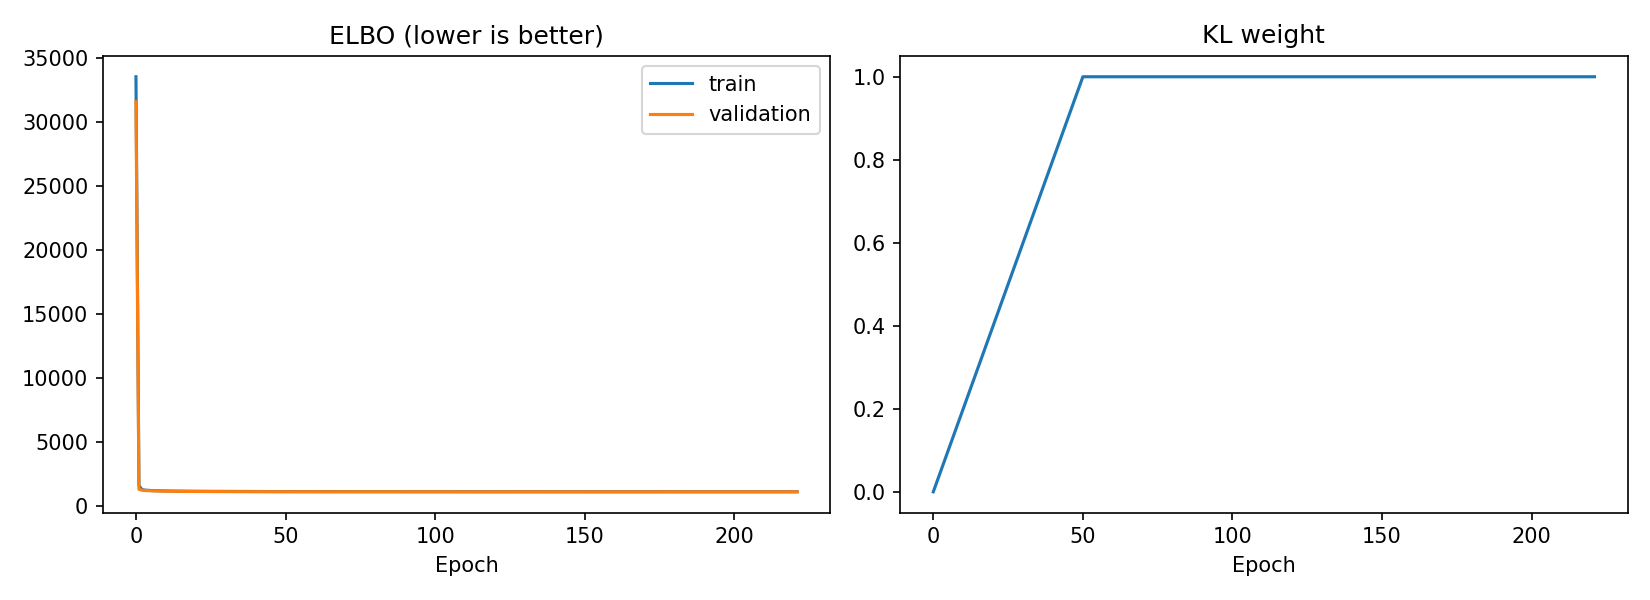

,metric,rna_pca,totalVI,change
0,cell_type_purity,0.919301,0.951349,0.032048
1,cell_type_entropy,0.050556,0.032624,-0.017933
2,cell_type_knn_label_agreement,0.950872,0.969353,0.018481
3,cell_type_silhouette,0.239678,0.146682,-0.092996
4,donor_purity,0.525258,0.765831,0.240574
5,donor_entropy,0.477235,0.227074,-0.250162
6,donor_knn_label_agreement,0.669048,0.860175,0.191127
7,donor_silhouette,-0.050653,0.047626,0.098279
8,site_purity,0.677907,0.917146,0.239238
9,site_entropy,0.440990,0.125390,-0.315600


,cell_type_harmonized,cell_type_purity,cell_type_entropy,cell_type_knn_label_agreement,cell_type_silhouette,donor_purity,donor_entropy,donor_knn_label_agreement,donor_silhouette,site_purity,site_entropy,site_knn_label_agreement,site_silhouette,n_evaluation_cells,space
0,B cells,0.992579,0.003012,0.993158,0.264185,0.509158,0.500891,0.682105,-0.024968,0.691526,0.445582,0.821579,-0.002002,1900,rna_pca
1,CD14 monocytes,0.979577,0.016982,0.992807,0.278635,0.601431,0.418595,0.763731,-0.077467,0.736457,0.378776,0.853749,-0.010530,4588,rna_pca
2,CD16 monocytes,0.941255,0.036473,0.965265,0.456336,0.514991,0.525178,0.683729,-0.057359,0.674954,0.472509,0.824497,-0.014774,547,rna_pca
3,CD4 T cells,0.831790,0.118098,0.932209,0.321446,0.539672,0.457303,0.676587,-0.059688,0.712798,0.381551,0.799934,-0.014590,3024,rna_pca
4,CD8 T cells,0.835603,0.086758,0.872659,-0.000742,0.688015,0.299899,0.781750,0.015748,0.797776,0.273702,0.864488,0.012705,2937,rna_pca
5,Erythroid populations,0.992546,0.004872,0.994181,0.348384,0.326323,0.646680,0.448878,-0.083164,0.484525,0.646179,0.581879,-0.020251,2406,rna_pca
6,G/M progenitors,0.757481,0.132358,0.795556,0.052926,0.344296,0.626030,0.464444,-0.051635,0.496444,0.638883,0.584444,0.001080,450,rna_pca
7,HSC,0.874366,0.091921,0.931759,0.300535,0.322572,0.672145,0.477690,-0.037756,0.472266,0.728583,0.648294,-0.007718,381,rna_pca
8,ILC,0.392593,0.248384,0.462963,0.174848,0.401852,0.619384,0.537037,-0.085698,0.606790,0.586549,0.796296,-0.024477,54,rna_pca
9,Lymphoid progenitors,0.934946,0.053879,0.970430,0.142433,0.280824,0.734874,0.465054,-0.028842,0.389964,0.845068,0.564516,-0.006506,372,rna_pca


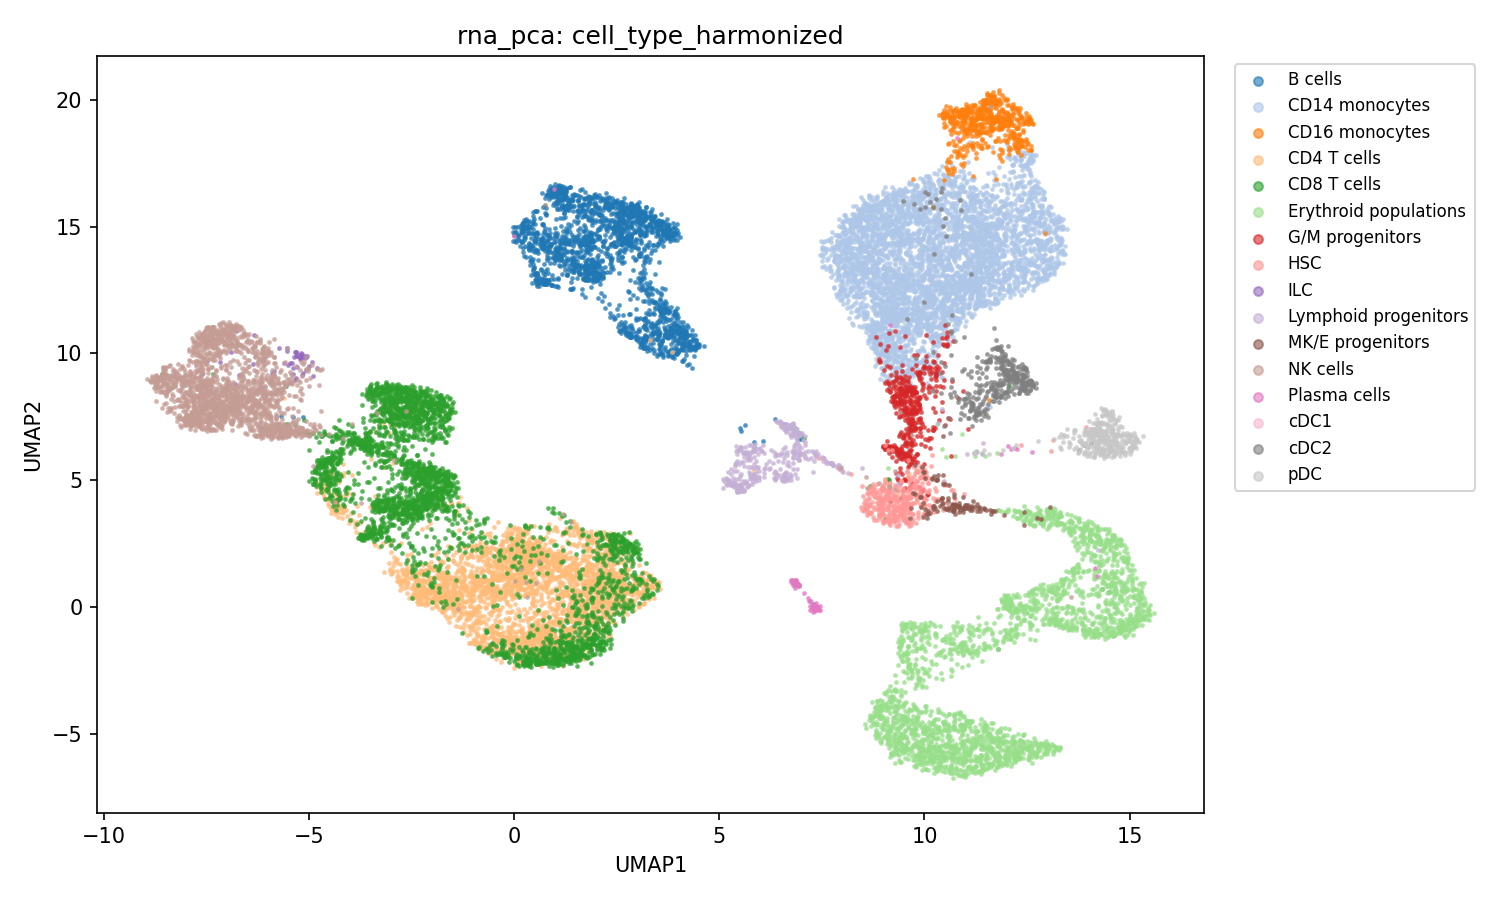

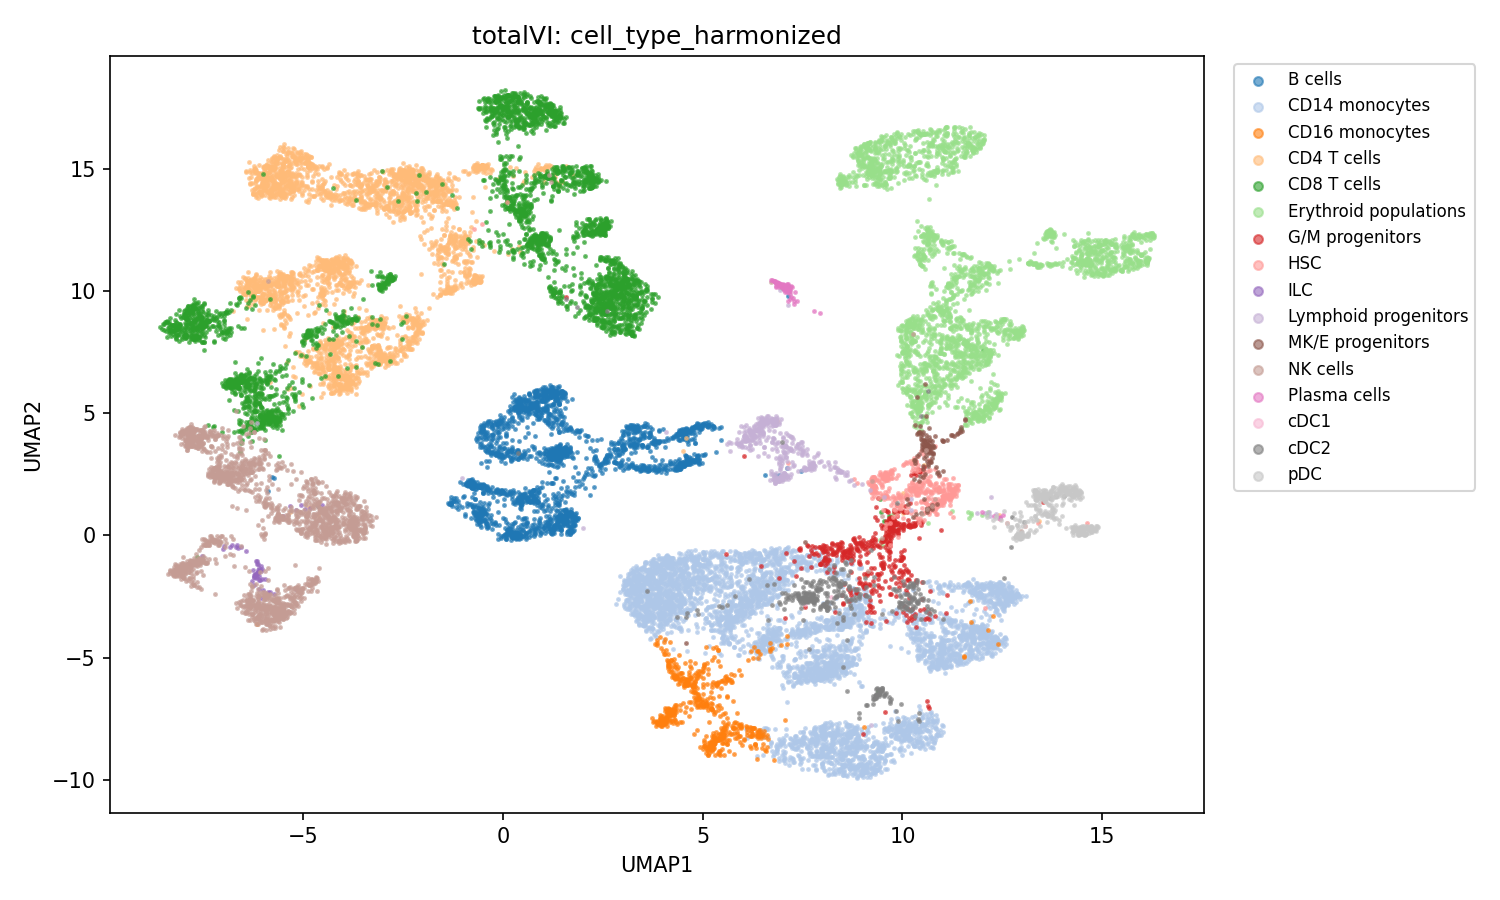

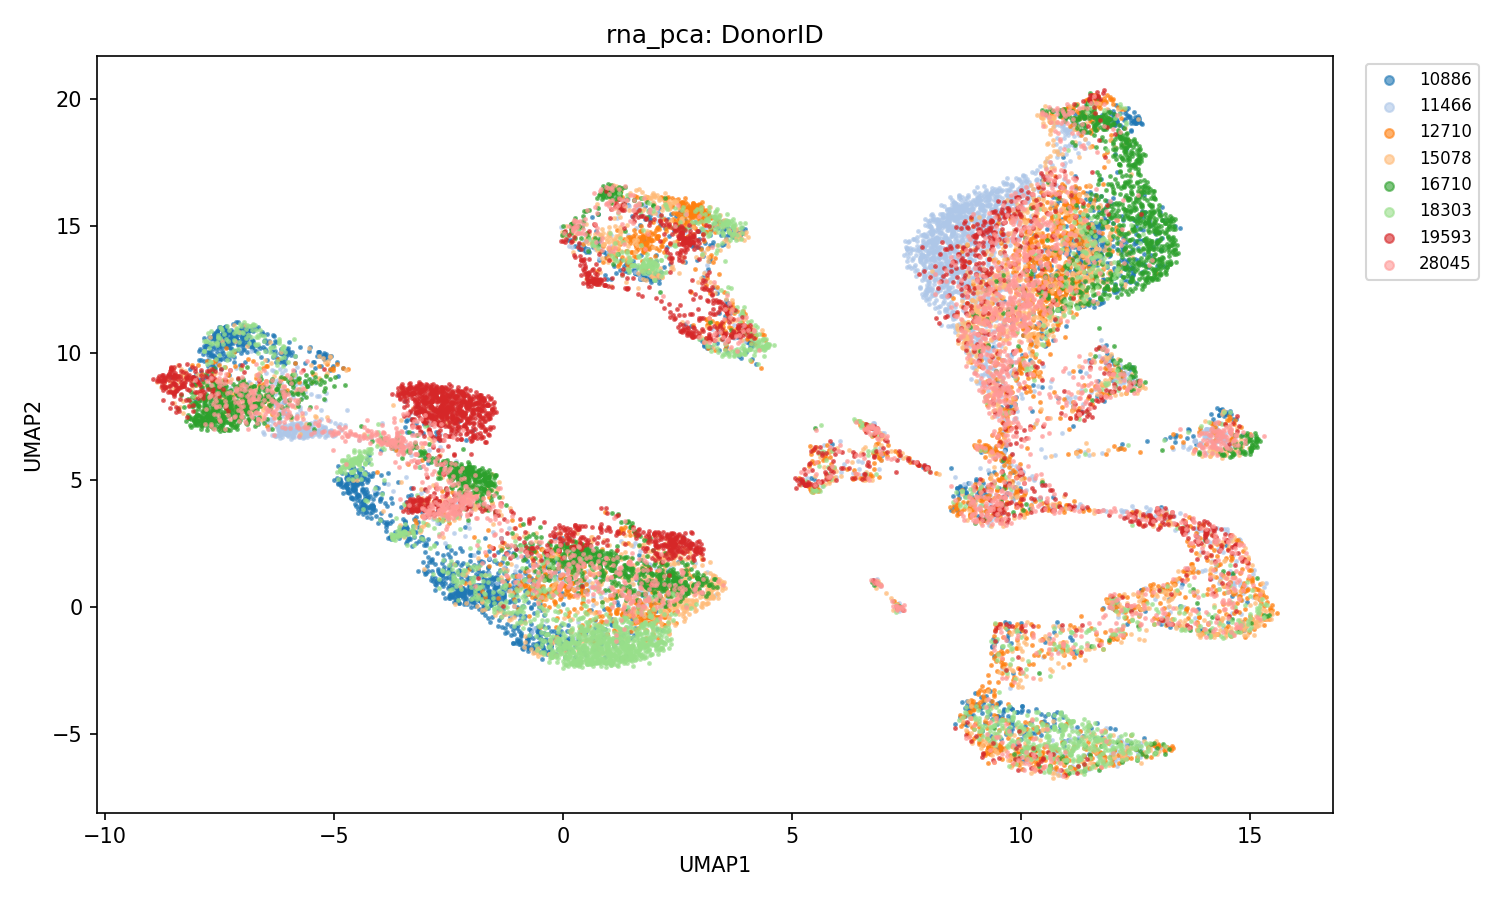

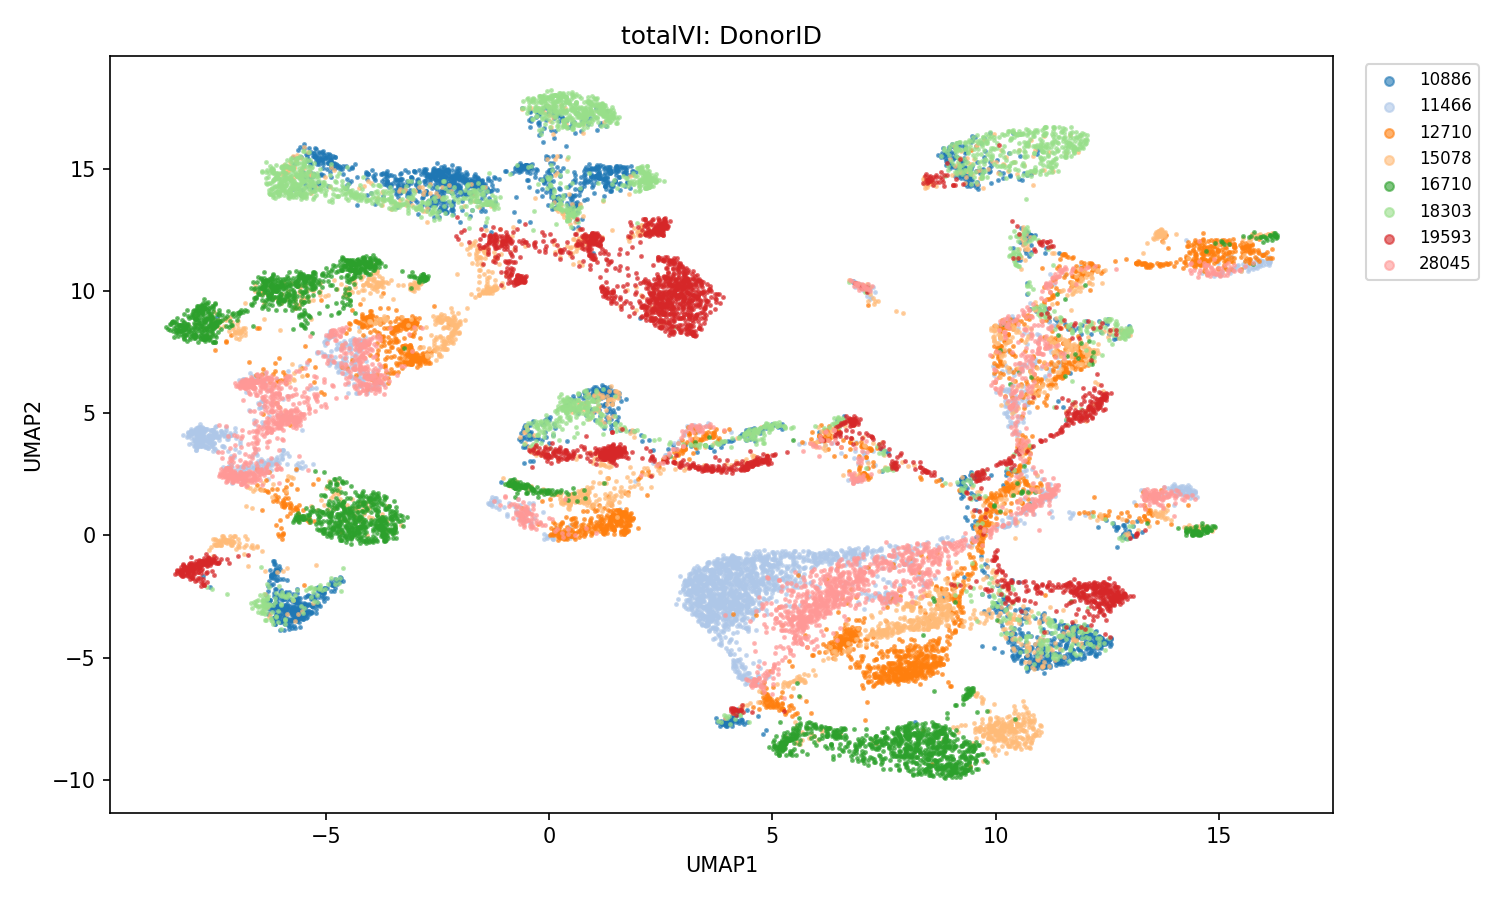

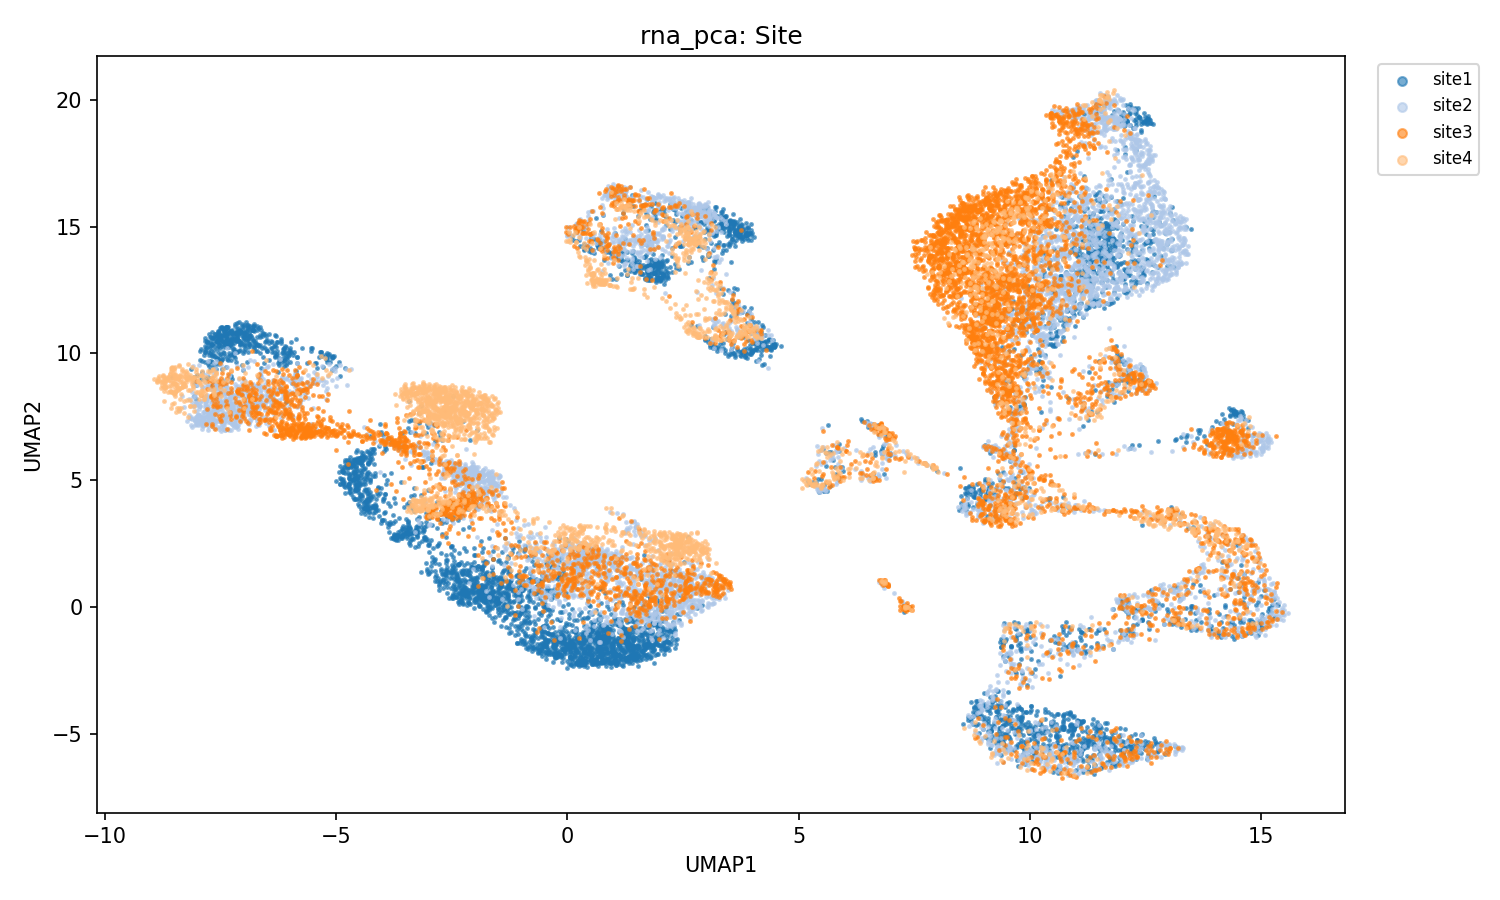

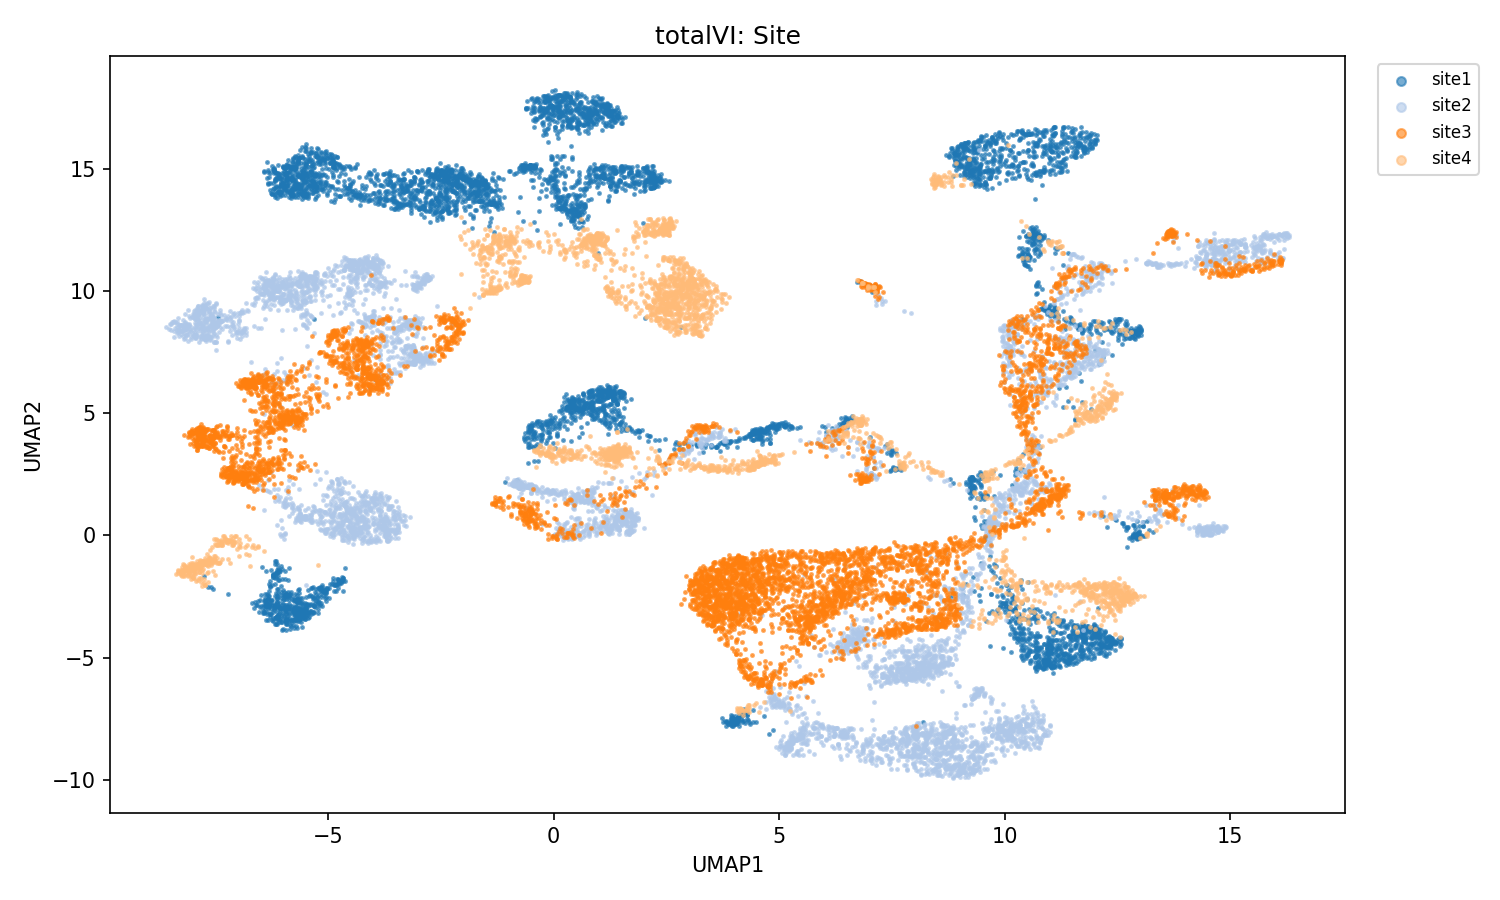

In [8]:
display(Image(filename=str(OUTPUT/'figures/training.png')))
display(comparison)
with pd.option_context('display.max_rows', None): display(types)
for field in ['cell_type_harmonized', 'DonorID', 'Site']:
    for space in ['rna_pca', 'totalVI']:
        display(Image(filename=str(OUTPUT/f'figures/{space}_{field}.png')))

## Protein consistency and sequencing depth
Protein neighbor agreement compares observed per-cell CLR protein abundance with
mean abundance among embedding neighbors (self excluded). CLR is diagnostic only.
An increase is expected when proteins enter the model: it is not held-out validation.
The observed protein means table allows inspection of broad lineage markers (for
example CD3/CD4/CD8, CD19, CD14, CD56 where measured). Neither means nor neighbor
correlations prove accurate protein denoising or cell-type annotation.

Inspect depth associations and population-specific losses, not only a visually
mixed UMAP. Maximum coordinate/depth correlations are descriptive and coordinate
system dependent; they do not identify a technical cause. Donor/site correlations
may include biology and should not automatically trigger stronger correction.

In [9]:
display(depths)
with pd.option_context('display.max_rows', None): display(proteins)
display(marker_means)

,space,depth,max_absolute_latent_spearman
0,rna_pca,rna_counts,0.378128
1,rna_pca,adt_counts,0.360598
2,totalVI,rna_counts,0.414644
3,totalVI,adt_counts,0.661512


,space,protein,neighbor_spearman,interpretation
0,rna_pca,CD86,0.799232,Internal consistency; proteins also train tota...
1,rna_pca,CD274,0.500162,Internal consistency; proteins also train tota...
2,rna_pca,CD270,0.431376,Internal consistency; proteins also train tota...
3,rna_pca,CD155,0.652431,Internal consistency; proteins also train tota...
4,rna_pca,CD112,0.579880,Internal consistency; proteins also train tota...
5,rna_pca,CD47,0.757315,Internal consistency; proteins also train tota...
6,rna_pca,CD48,0.859152,Internal consistency; proteins also train tota...
7,rna_pca,CD40,0.535036,Internal consistency; proteins also train tota...
8,rna_pca,CD154,0.623890,Internal consistency; proteins also train tota...
9,rna_pca,CD52,0.799796,Internal consistency; proteins also train tota...


,cell_type_harmonized,CD86,CD274,CD270,CD155,CD112,CD47,CD48,CD40,CD154,...,CD94,CD162,CD85j,CD23,CD328,HLA-E,CD82,CD101,CD88,CD224
0,B cells,-1.511083,-0.282016,0.886757,-1.167096,-0.220742,1.966262,1.479321,0.966883,0.797729,...,-0.232792,0.068643,-0.292064,0.819872,-1.642011,0.439066,1.313788,-0.381668,0.273691,-0.159526
1,CD4 T cells,-1.521415,-0.380603,0.738059,-1.089846,-0.275983,2.361283,2.532402,-0.547778,0.762142,...,-0.287080,1.920247,-0.792262,0.524459,-1.449110,0.473253,1.137330,0.709007,0.084255,0.517544
2,CD8 T cells,-1.708806,-0.400019,0.710767,-1.178752,-0.276149,2.062981,2.361594,-0.574938,0.681732,...,0.361014,2.008264,-0.537121,0.566785,-1.575033,0.736001,-0.000746,1.079390,0.163246,0.084699
3,CD14 monocytes,-0.105773,-0.414550,0.453693,-0.283800,0.104716,1.266561,1.544963,-0.488879,0.720845,...,-0.286087,1.379817,-0.188373,0.530500,0.910589,0.258645,0.408409,1.173784,0.700121,0.983096
4,CD16 monocytes,0.379937,-0.433146,0.586113,-0.504212,-0.073830,1.682929,1.897935,-0.188629,0.681203,...,-0.304324,2.219254,0.298552,0.539021,0.505949,0.537315,-0.434484,1.452922,1.414687,0.336148
5,Erythroid populations,-1.258326,0.124335,0.735331,-0.534822,0.214065,1.800784,-0.460727,-0.102747,1.322229,...,0.242232,-0.272044,0.006338,1.024685,-1.130531,0.399291,1.257172,-0.036079,2.142827,0.254366
6,G/M progenitors,-0.102343,-0.131228,0.606346,-0.018192,0.896488,1.224439,1.007980,-0.372120,0.930733,...,-0.024846,1.550019,-0.249514,0.763552,-0.134996,0.321093,0.562341,0.228106,0.364447,1.105928
7,HSC,-1.132565,-0.085136,0.709898,0.143167,1.732234,1.604192,0.294510,-0.198698,0.994421,...,0.093963,0.797593,-0.421198,0.823346,-1.099602,0.339707,0.941923,-0.133643,0.447431,0.902702
8,ILC,-1.733111,-0.670575,0.729125,-1.256874,-0.490227,2.450192,2.084957,-0.799570,0.544634,...,2.746866,2.235399,-0.852790,0.392270,1.798073,0.749502,-0.305640,0.026730,0.203701,-0.508407
9,Lymphoid progenitors,-1.379407,-0.000471,0.667179,-0.838990,0.258646,2.335063,1.037389,-0.272777,1.026134,...,0.080466,-0.333967,-0.314246,0.875396,-1.312755,0.515919,0.599743,-0.209184,0.448394,0.114343


## Findings and decision after execution
Record training convergence, broad cell identity, rare-type limitations, observed
protein marker patterns, and donor/site/depth associations. No result is assumed
before execution. These are descriptive internal checks, not donor-independent
validation or a causal analysis. Do not treat cells as independent human replicates.

The next separate workflow can fit MultiVI to paired Multiome RNA and ATAC peak
counts. Separate totalVI/MultiVI latent coordinates cannot simply be concatenated
or compared dimension-by-dimension; cross-capture alignment requires evaluation.

## Saved outputs
model_input.h5ad stores normalized HVG X for PCA, raw HVG counts, raw ADT, metadata
and totalVI coordinates. model/ stores weights and registry. The input is saved
before training and the model before evaluation, allowing recovery without retraining.
CSV tables, UMAP coordinates, PNG figures, training histories, input audits and
manifest remain in OUTPUT. LOAD mode reads only saved outputs. To load a trained
model manually use TOTALVI.load with model_input.h5ad in its saved gene/protein order.